# Anomaly Detections
1. Anomaly Detection
>>Anomaly Detection is the process of identifying unusual patterns in data that do not conform to expected behavior.
Types:
i. Point Anomaly
A single data point is abnormal
 Example: A ₹10,000 transaction in a normal ₹500 pattern
ii. Contextual Anomaly
Depends on context (time/location)
Example: High temperature in winter
iii. Collective Anomaly
A group of points is abnormal
Example: Sudden spike in network traffic

2. Isolation Forest vs DBSCAN vs LOF
>>Algorithm	/Approach	/Use Case
Isolation Forest	/Random tree isolation	/Large datasets
DBSCAN	/Density-based clustering	/Spatial data
LOF/	Local density comparison	/Detect local outliers

3. Components of Time Series
>>Trend – Long-term movement
 Example: Increasing sales
Seasonality – Repeating pattern
 Example: Ice cream sales in summer
Cyclical – Economic cycles
 Example: Business cycles
Noise – Random variation

4. Stationarity
>>A time series is stationary if men, variance, and covariance are constant over time.
Testing:
Augmented Dickey-Fuller (ADF) test
Transformation:
Differencing
Log transformation
Smoothing

5. AR, MA, ARIMA, SARIMA, SARIMAX
>>Model	Description
AR	Uses past values
MA	Uses past errors
ARIMA	AR + MA + differencing
SARIMA	ARIMA + seasonality
SARIMAX	SARIMA + external variables


10. Real-Time Workflow
 >>I. Anomaly Detection
Use Isolation Forest for streaming
LOF for local anomalies
DBSCAN for clustering
II. Forecasting Model
Use SARIMAX (includes weather + region data)
III. Validation
Metrics: MAE, RMSE
Cross-validation
Monitor drift
IV. Monitoring
Real-time dashboards
Alert system for anomalies
V. Business Impact
Prevent power failures
Optimize energy usage
Improve grid stability

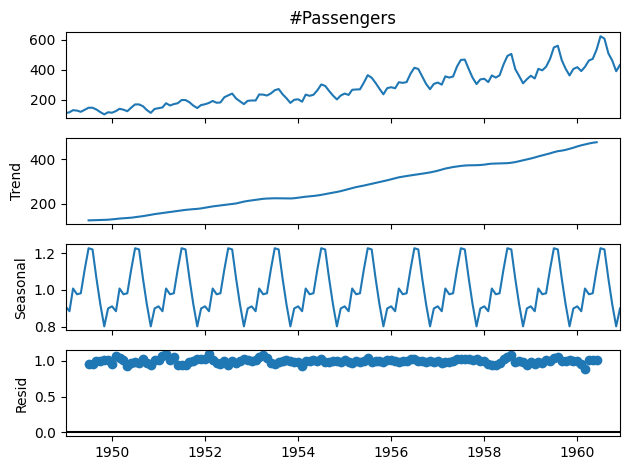

In [3]:
#6. Time Series Decomposition
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

data = pd.read_csv('/content/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

decomposition = seasonal_decompose(data['#Passengers'], model='multiplicative')

decomposition.plot()
plt.show()

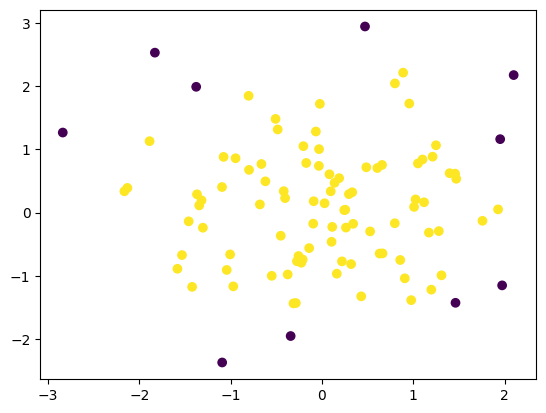

In [2]:
#7. Isolation Forest
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

data = np.random.randn(100, 2)

model = IsolationForest(contamination=0.1)
pred = model.fit_predict(data)

plt.scatter(data[:,0], data[:,1], c=pred)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


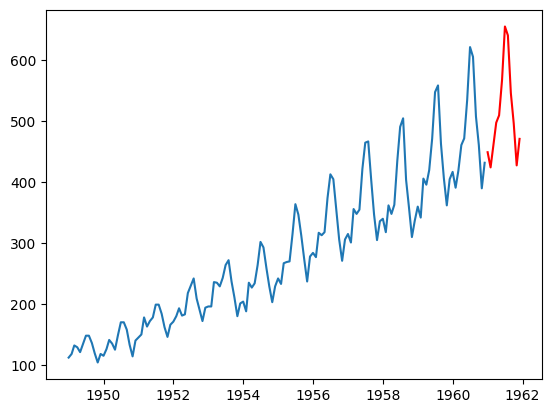

In [5]:
#8. SARIMA Forecast
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

data = pd.read_csv('/content/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

model = SARIMAX(data['#Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.forecast(steps=12)

plt.plot(data.index, data['#Passengers'])
plt.plot(forecast.index, forecast, color='red')
plt.show()

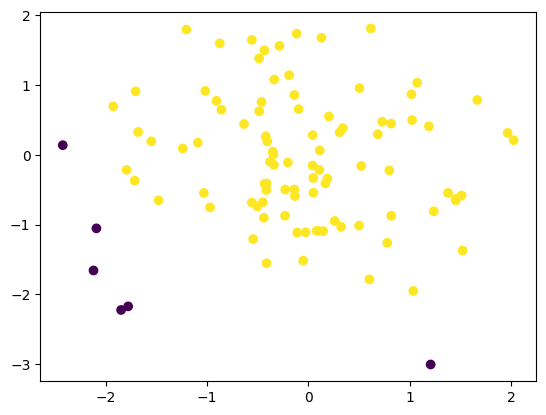

In [6]:
#9. LOF
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import matplotlib.pyplot as plt

data = np.random.randn(100, 2)

lof = LocalOutlierFactor(n_neighbors=20)
pred = lof.fit_predict(data)

plt.scatter(data[:,0], data[:,1], c=pred)
plt.show()